# Customer x Product Bridge EDA

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in cell 1 for full dataset analysis (production)
- Set `USE_SAMPLE = True` in cell 1 for quick sample testing (development)

Objective: Connect customer behavior segments with product/category preferences.

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False
TOP_DEPARTMENTS = 8

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from instacart_quality import load_eda_base

# Load clean base tables directly
tables = load_eda_base(use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)
orders = tables["orders"]
order_products = tables["order_products_prior"]
products = tables["products"]
departments = tables["departments"]

# Merge to enrich order_products with order info and department
df = order_products.merge(orders, on="order_id", how="left").merge(
    products[["product_id", "department_id"]], on="product_id", how="left"
).merge(departments, on="department_id", how="left")

print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,department_id,department
0,28,35108,1,0,98256,prior,29,3,13,6.0,16,dairy eggs
1,28,40593,2,1,98256,prior,29,3,13,6.0,16,dairy eggs
2,28,17461,3,0,98256,prior,29,3,13,6.0,12,meat seafood
3,28,22825,4,1,98256,prior,29,3,13,6.0,4,produce
4,28,25256,5,1,98256,prior,29,3,13,6.0,16,dairy eggs


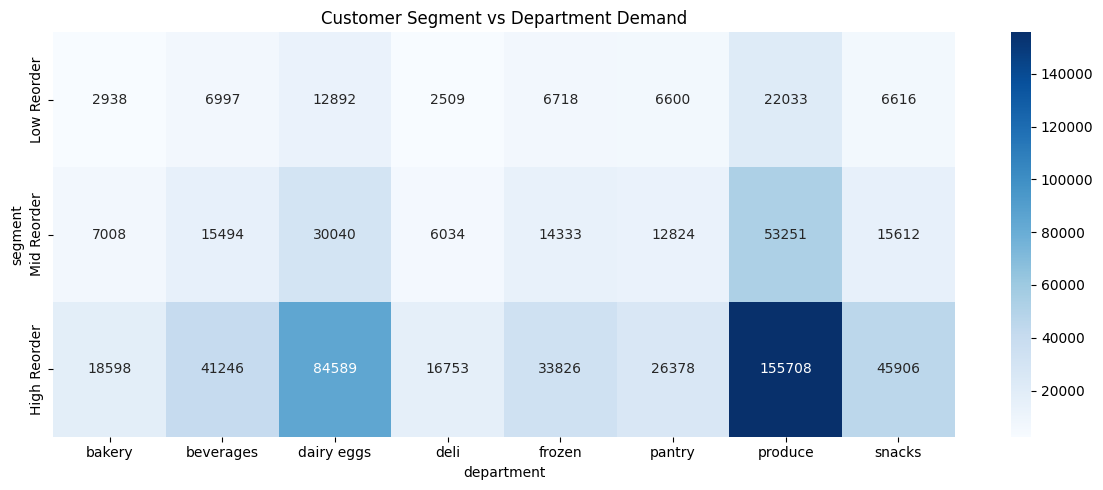

In [2]:
customer_profile = (
    df.groupby("user_id")
    .agg(
        reorder_rate=("reordered", "mean"),
        avg_basket_pos=("add_to_cart_order", "mean"),
        total_lines=("product_id", "count"),
    )
    .reset_index()
)
customer_profile["segment"] = pd.qcut(
    customer_profile["reorder_rate"],
    q=3,
    labels=["Low Reorder", "Mid Reorder", "High Reorder"],
)

bridge = df.merge(customer_profile[["user_id", "segment"]], on="user_id", how="left")
heat = (
    bridge.groupby(["segment", "department"]).size().rename("order_lines").reset_index()
)
top_departments = (
    heat.groupby("department")["order_lines"].sum().sort_values(ascending=False).head(TOP_DEPARTMENTS).index
)
heat = heat[heat["department"].isin(top_departments)]
pivot = heat.pivot(index="segment", columns="department", values="order_lines").fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Customer Segment vs Department Demand")
plt.tight_layout()
plt.show()